# Learning Objectives

After completing this notebook, you will be able to:

- Understand Gradient Descent visually.
- Understand why gradients move towards minimum loss.
- Understand the effect of different learning rates.
- Understand Overshooting.
- Compare small and large learning rates.
- Build intuition before learning SGD and Adam.

# Theory

Gradient Descent is one of the most important optimization algorithms in Deep Learning.

Its goal is very simple:

Find the values of weights that produce the minimum possible loss.

Instead of randomly changing the weights, Gradient Descent uses the gradient (slope) to determine the best direction for updating weights.

Weight Update Formula:

W(new) = W(old) − Learning Rate × Gradient

Where:

- W = Weight
- Learning Rate = Step Size
- Gradient = Direction of Maximum Increase in Loss

Since we want to minimize the loss, we move in the opposite direction of the gradient.

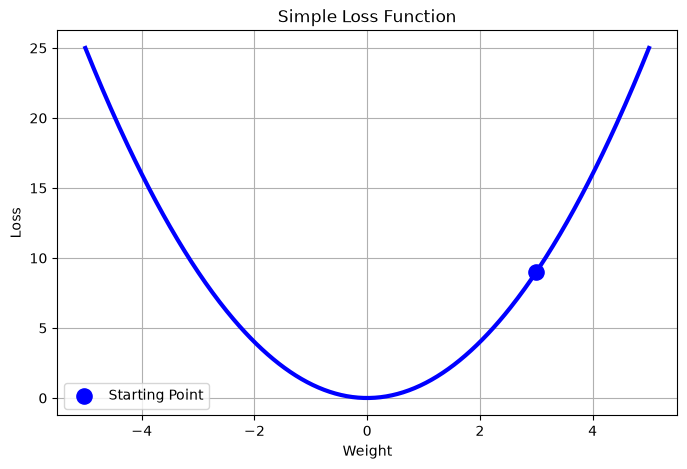

In [8]:
# Visualizing a Loss Function

import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-5,5,400)
loss = x**2

plt.figure(figsize=(8,5))
plt.plot(x, loss, linewidth = 3, color = "blue")

plt.scatter(3, 9, s = 120, label = "Starting Point", color = "blue")

plt.title("Simple Loss Function")
plt.xlabel("Weight")
plt.ylabel("Loss")

plt.grid(True)
plt.legend()

plt.show()

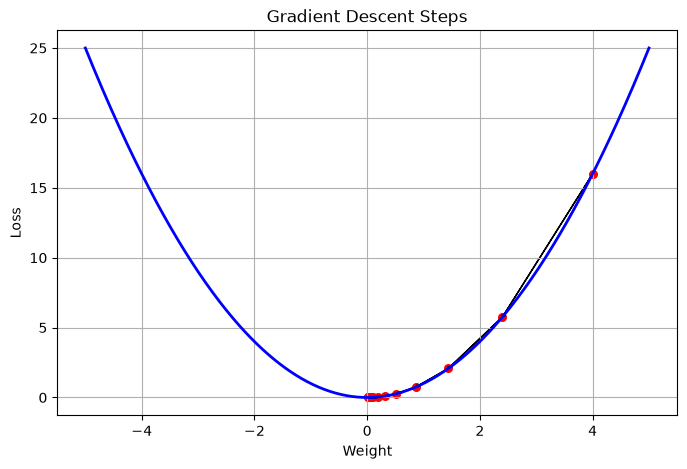

In [17]:
# Gradient Descent Path

import numpy as np
import matplotlib.pyplot as plt


def loss(x):
    return x**2


learning_rate = 0.2
weight = 4

weights = [weight]

for _ in range(12):
    gradient = 2 * weight
    weight = weight - learning_rate * gradient
    weights.append(weight)

x = np.linspace(-5,5,400)

plt.figure(figsize=(8,5))
plt.plot(x, loss(x), linewidth = 2, color = "blue")

plt.scatter(weights, loss(np.array(weights)), color = "red", s = 30)

for i in range(len(weights)-1):
    plt.arrow(weights[i],
              loss(weights[i]),
              weights[i+1]-weights[i],
              loss(weights[i+1])-loss(weights[i]),
              head_width=0.08,
              length_includes_head=True)

plt.title("Gradient Descent Steps")
plt.xlabel("Weight")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

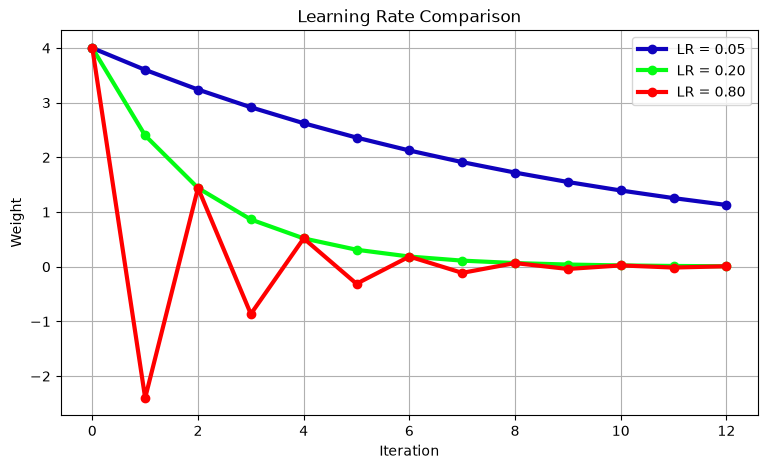

In [45]:
# Learning Rate Comparison

import numpy as np
import matplotlib.pyplot as plt


def train(lr):

    w = 4
    history = [w]

    for _ in range(12):
        grad = 2*w
        w = w - lr*grad
        history.append(w)

    return history


small = train(0.05)
normal = train(0.2)
large = train(0.8)

plt.figure(figsize=(9,5))

plt.plot(small, marker = "o", label = "LR = 0.05", linewidth = 3, color = "#0f02bd")
plt.plot(normal, marker = "o", label = "LR = 0.20", linewidth = 3, color = "#03fc13")
plt.plot(large, marker = "o", label = "LR = 0.80", linewidth = 3, color = "red")

plt.title("Learning Rate Comparison")
plt.xlabel("Iteration")
plt.ylabel("Weight")

plt.grid(True)
plt.legend()

plt.show()

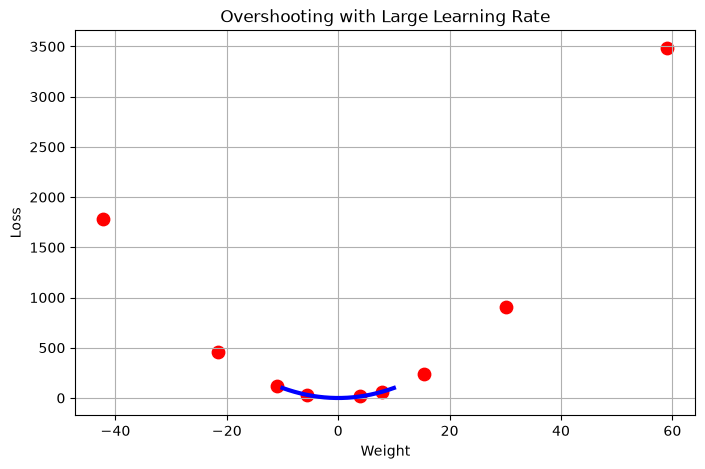

In [27]:
# Overshooting Demonstration

import numpy as np
import matplotlib.pyplot as plt


weight = 4
lr = 1.2

history = [weight]

for _ in range(8):

    gradient = 2*weight
    weight = weight - lr*gradient

    history.append(weight)

x = np.linspace(-10,10,500)

plt.figure(figsize=(8,5))

plt.plot(x, x ** 2, linewidth = 3, color = "blue")

plt.scatter(history, np.array(history)**2, color = "red", s = 80)

plt.title("Overshooting with Large Learning Rate")
plt.xlabel("Weight")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

# Notebook Explanation (Part 1)

## Program 1 - Loss Function

This graph represents a simple quadratic loss function.

- The center of the curve is the minimum loss.
- The farther away the weight moves from the center, the larger the loss becomes.

This is the destination Gradient Descent tries to reach.

---

## Program 2 - Gradient Descent

The red points show how the model updates its weight after every iteration.

Each step moves closer to the minimum loss.

Notice that every update is smaller than the previous one because the gradient becomes smaller near the minimum.

---

## Program 3 - Learning Rate Comparison

Three different learning rates are compared.

- Small Learning Rate → Stable but Slow.
- Medium Learning Rate → Fast and Stable.
- Large Learning Rate → Very Fast but may become unstable.

Choosing a suitable learning rate is one of the most important hyperparameter decisions in Deep Learning.

---

## Program 4 - Overshooting

This visualization demonstrates what happens when the learning rate is too large.

Instead of stopping at the minimum point, the optimizer jumps over it repeatedly.

This behavior is called **Overshooting** and may prevent the model from converging.

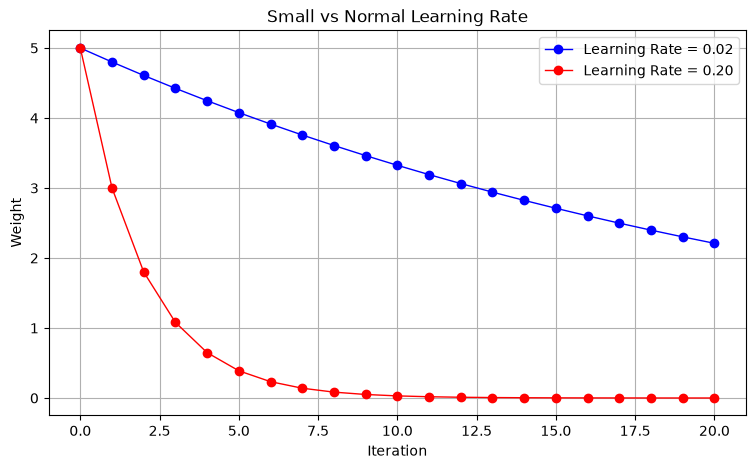

In [40]:
# Small vs Normal Learning Rate

import numpy as np
import matplotlib.pyplot as plt


def gradient_descent(lr, iterations=20):
    weight = 5
    history = [weight]

    for _ in range(iterations):
        gradient = 2 * weight
        weight = weight - lr * gradient
        history.append(weight)

    return history


small_lr = gradient_descent(0.02)
normal_lr = gradient_descent(0.20)

plt.figure(figsize=(9,5))

plt.plot(small_lr, marker='o', linewidth=1, label="Learning Rate = 0.02", color = "blue")
plt.plot(normal_lr, marker='o', linewidth=1, label="Learning Rate = 0.20", color = "red")

plt.title("Small vs Normal Learning Rate")
plt.xlabel("Iteration")
plt.ylabel("Weight")

plt.grid(True)
plt.legend()

plt.show()

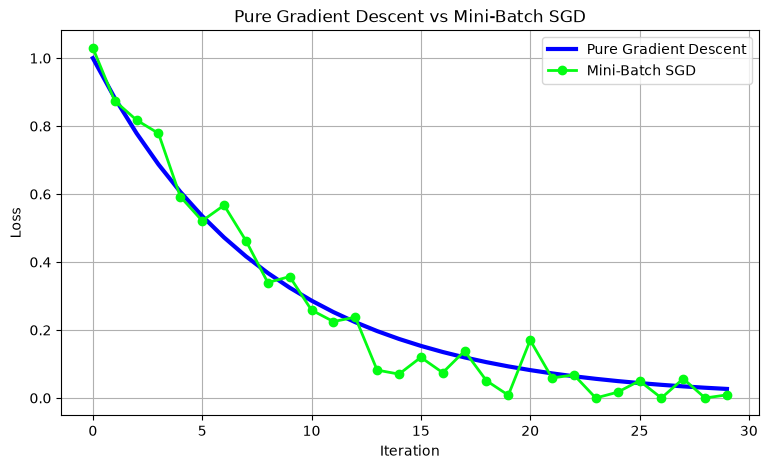

In [41]:
# Pure Gradient Descent vs Mini-Batch SGD(Stochastic Gradient Descent)

import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

iterations = np.arange(30)

pure_gd = np.exp(-iterations / 8)

noise = np.random.normal(0, 0.06, size=len(iterations))
mini_batch = pure_gd + noise

mini_batch = np.clip(mini_batch, 0, None)

plt.figure(figsize=(9,5))

plt.plot(iterations, pure_gd,
         linewidth=3,
         label="Pure Gradient Descent", color = "blue")

plt.plot(iterations, mini_batch,
         linewidth=2,
         marker='o',
         label="Mini-Batch SGD", color = "#03fc13")

plt.title("Pure Gradient Descent vs Mini-Batch SGD")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.grid(True)
plt.legend()

plt.show()

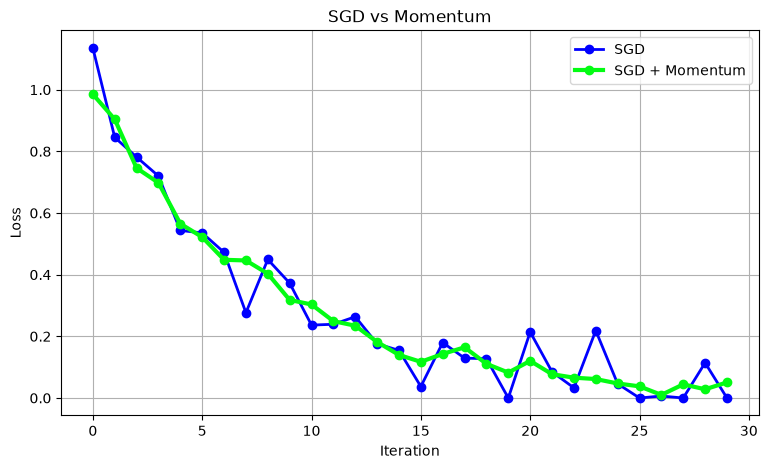

In [42]:
# SGD vs Momentum

import numpy as np
import matplotlib.pyplot as plt


np.random.seed(7)

iterations = np.arange(30)

sgd = np.exp(-iterations / 8)
sgd += np.random.normal(0, 0.08, len(iterations))

momentum = np.exp(-iterations / 8)
momentum += np.random.normal(0, 0.02, len(iterations))

sgd = np.clip(sgd, 0, None)
momentum = np.clip(momentum, 0, None)

plt.figure(figsize=(9,5))

plt.plot(iterations,
         sgd,
         marker='o',
         linewidth=2,
         label="SGD", color = "blue")

plt.plot(iterations,
         momentum,
         marker='o',
         linewidth=3,
         label="SGD + Momentum", color = "#03fc13")

plt.title("SGD vs Momentum")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.grid(True)
plt.legend()

plt.show()

# Notebook Explanation (Part 2)

The purpose of this notebook is to develop an intuitive understanding of how Gradient Descent updates model parameters to minimize the loss function.

---

## Program 5 - Small vs Normal Learning Rate

This visualization compares two learning rates.

- A very small learning rate takes tiny steps toward the minimum.
- A normal learning rate reaches the minimum much faster.
- Choosing a suitable learning rate improves training speed without sacrificing stability.

---

## Program 6 - Pure Gradient Descent vs Mini-Batch SGD

This comparison demonstrates the difference between two optimization approaches.

- Pure Gradient Descent follows a smooth path because it uses the entire dataset to compute each gradient.
- Mini-Batch SGD introduces small fluctuations because gradients are estimated using only a subset of the data.
- Despite the zig-zag movement, Mini-Batch SGD usually reaches the minimum much faster and is more practical for large datasets.

---

## Program 7 - SGD vs Momentum

Momentum builds upon SGD by remembering part of the previous update.

- SGD frequently changes direction, creating a zig-zag optimization path.
- Momentum smooths these updates by maintaining part of the previous movement.
- As a result, Momentum converges faster and follows a more stable path toward the minimum.

---

# Key Takeaways

- Gradient Descent minimizes the loss by updating weights.
- Learning Rate controls the size of each update.
- Very small learning rates lead to slow convergence.
- Very large learning rates may cause overshooting.
- Mini-Batch SGD is the preferred optimization strategy for large datasets.
- Momentum reduces unnecessary oscillations and accelerates convergence.

# Experiment Yourself

Try changing the following values and observe the results:

- Learning Rate (0.01, 0.05, 0.5, 1.0)
- Initial Weight (2, 5, 10)
- Number of Iterations
- Noise Level in Mini-Batch SGD
- Compare SGD with Momentum under different noise conditions.

Observe how these changes affect convergence speed and training stability.